# Observationally driven Galactic double-white-dwarf population for LISA

This notebook generates an observationally motivated Galactic DWD population based on [Maoz et al. (2018)](https://arxiv.org/abs/1801.04275), writes a catalogue, and produces basic diagnostic plots. 

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const
from astropy import units as u
from astropy.coordinates import BarycentricTrueEcliptic, SkyCoord, BarycentricMeanEcliptic
from astropy.time import Time

# Reproducible random-number generator
SEED = 3791
rng = np.random.default_rng(SEED)

# One ecliptic frame is used throughout the notebook
ECLIPTIC_FRAME = BarycentricMeanEcliptic()

plt.rc("font", family="serif")
plt.rc("text", usetex=False)


## Model and catalogue settings

The full Galactic population estimate is reported for context, while a smaller sample is
used for this demonstration.


In [27]:
# Population estimate
V_DISC = 6.0e11      # pc^3; integrated disc volume
RHO_WD = 4.49e-3     # pc^-3; local white-dwarf space density
F_DWD = 0.01         # DWDs per single white dwarf
N_ESTIMATED = int(V_DISC * RHO_WD * F_DWD)


N = N_ESTIMATED
T_DISC = 10.0 * u.Gyr # LSS - age of MW disk stellar population
ALPHA = -1.3 # LSS power law index of the DWD orbital separation distribution
F_MIN = 1.0e-4 * u.Hz # LSS min freq of LISA.
OUTPUT_FILE = Path(f"../datasets/dwd_datasets/DWD_obs_based_population_N{N}.txt")

print(f"Estimated Galactic population: {N_ESTIMATED / 1e6:.2f} million DWDs")
print(f"Demo catalogue size: {N:,} binaries")


Estimated Galactic population: 26.94 million DWDs
Demo catalogue size: 26,940,000 binaries


## Helper functions

### Component masses

The primary mass follows a three-component Gaussian mixture with means
$\{0.649,0.57,0.81\}\,M_\odot$, standard deviations
$\{0.04,0.097,0.187\}\,M_\odot$, and weights $\{0.81,0.14,0.05\}$.
The secondary mass is drawn uniformly between $0.15\,M_\odot$ and $m_1$.
For systems with $m_1<0.25\,M_\odot$, the companion is instead drawn uniformly
from $[0.2,1.2]\,M_\odot$.


In [28]:
def sample_truncated_normal(n, mean, sigma, lower, upper, rng):
    """Draw ``n`` samples from a normal distribution truncated to [lower, upper]."""
    if n == 0:
        return np.empty(0)

    samples = np.empty(n)
    filled = 0

    while filled < n:
        batch_size = max(2 * (n - filled), 100)
        draws = rng.normal(mean, sigma, batch_size)
        accepted = draws[(draws >= lower) & (draws <= upper)]
        n_take = min(accepted.size, n - filled)
        samples[filled:filled + n_take] = accepted[:n_take]
        filled += n_take

    return samples


def generate_component_masses(n, rng):
    """Generate observationally motivated DWD component masses in solar masses."""
    weights = np.array([0.81, 0.14, 0.05])
    means = np.array([0.649, 0.57, 0.81])
    sigmas = np.array([0.040, 0.097, 0.187])

    counts = np.floor(n * weights).astype(int)
    counts[-1] = n - counts[:-1].sum()

    m1 = np.concatenate([
        sample_truncated_normal(count, mean, sigma, 0.15, 1.40, rng)
        for count, mean, sigma in zip(counts, means, sigmas)
    ])
    rng.shuffle(m1)

    m2 = rng.uniform(0.15, m1)
    low_mass_primary = m1 < 0.25
    m2[low_mass_primary] = rng.uniform(0.20, 1.20, low_mass_primary.sum())

    return m1 * u.Msun, m2 * u.Msun


### Present-day GW-frequency distribution

For a constant DWD formation rate over the disc age $t_0$, the present-day separation
distribution is sampled in terms of $x=a/(K t_0)^{1/4}$, where

$$
K=\frac{256}{5}\frac{G^3}{c^5}m_1m_2(m_1+m_2).
$$

The minimum separation is set by Roche-lobe contact. The maximum separation is calculated
separately for every binary from the lower GW-frequency cutoff $f_{\rm min}$.


In [29]:
def white_dwarf_radius(mass):
    """Approximate WD radius: R = 0.0127 R_sun (M/M_sun)^(-1/3)."""
    return 0.0127 * const.R_sun * (mass / const.M_sun) ** (-1.0 / 3.0)


def roche_contact_separation(radius, mass_ratio):
    """Binary separation at which a star fills its Eggleton Roche lobe."""
    q13 = mass_ratio ** (1.0 / 3.0)
    roche_fraction = 0.49 * q13**2 / (0.6 * q13**2 + np.log1p(q13))
    return radius / roche_fraction


def present_day_separation_pdf(x, alpha):
    """Unnormalised universal present-day separation distribution."""
    x = np.asarray(x, dtype=float)

    if np.isclose(alpha, -1.0):
        density = x**3 * np.log1p(x**-4)
    else:
        exponent = (alpha + 1.0) / 4.0
        density = x ** (4.0 + alpha) * np.expm1(
            exponent * np.log1p(x**-4)
        )

    # For alpha < -1 the proportional expression is negative; only its
    # normalised shape is relevant.
    return np.abs(density)


def cumulative_trapezoid(y, x):
    """Cumulative trapezoidal integral with an initial value of zero."""
    increments = 0.5 * (y[1:] + y[:-1]) * np.diff(x)
    return np.concatenate(([0.0], np.cumsum(increments)))


def sample_gw_frequency(m1, m2, t_disc, f_min, alpha, rng, grid_size=10_000):
    """Sample present-day GW frequencies for a DWD population."""
    if m1.shape != m2.shape:
        raise ValueError("m1 and m2 must have the same shape.")
    if np.any(m1 <= 0 * u.kg) or np.any(m2 <= 0 * u.kg):
        raise ValueError("All component masses must be positive.")
    if f_min <= 0 * u.Hz:
        raise ValueError("f_min must be positive.")

    merger_constant = (
        (256.0 / 5.0)
        * const.G**3 / const.c**5
        * m1 * m2 * (m1 + m2)
    )
    separation_scale = (merger_constant * t_disc.to(u.s)) ** 0.25

    # Contact separation: use whichever star fills its Roche lobe first.
    radius1 = white_dwarf_radius(m1)
    radius2 = white_dwarf_radius(m2)
    q1 = (m1 / m2).to_value(u.dimensionless_unscaled)
    q2 = (m2 / m1).to_value(u.dimensionless_unscaled)

    a_contact1 = roche_contact_separation(radius1, q1)
    a_contact2 = roche_contact_separation(radius2, q2)
    a_min = np.maximum(
        a_contact1.to_value(u.m),
        a_contact2.to_value(u.m),
    ) * u.m

    # For f_GW = (1/pi) sqrt(G M_tot / a^3).
    total_mass = m1 + m2
    a_max = (const.G * total_mass / (np.pi**2 * f_min**2)) ** (1.0 / 3.0)

    invalid = a_min >= a_max
    if np.any(invalid):
        raise ValueError(
            f"{invalid.sum()} systems have a contact frequency below f_min."
        )

    x_min = (a_min / separation_scale).to_value(u.dimensionless_unscaled)
    x_max = (a_max / separation_scale).to_value(u.dimensionless_unscaled)

    x_grid = np.logspace(
        np.log10(0.9 * x_min.min()),
        np.log10(1.1 * x_max.max()),
        grid_size,
    )
    pdf = present_day_separation_pdf(x_grid, alpha)
    cdf = cumulative_trapezoid(pdf, x_grid)
    cdf /= cdf[-1]

    cdf_min = np.interp(x_min, x_grid, cdf)
    cdf_max = np.interp(x_max, x_grid, cdf)
    targets = cdf_min + rng.random(m1.size) * (cdf_max - cdf_min)

    x_sample = np.interp(targets, cdf, x_grid)
    separation = x_sample * separation_scale
    frequency = np.sqrt(const.G * total_mass / separation**3) / np.pi

    return frequency.to(u.Hz)


### Galactic positions and ecliptic sky coordinates

The Galactic disc uses a $\mathrm{sech}^2(z/h_z)$ vertical profile with
$h_z=0.3$ kpc. The Sun is placed at $(R_\odot,z_\odot)=(8.1,0.03)$ kpc.
The sampled Galactic directions are transformed with Astropy into the same
J2000 barycentric true-ecliptic frame used by the sky-plot overlays.


In [30]:
def wrap_to_pi(angle):
    """Wrap angles in radians to [-pi, pi]."""
    return (np.asarray(angle) + np.pi) % (2.0 * np.pi) - np.pi


def sample_galactic_positions(n, rng, ecliptic_frame=ECLIPTIC_FRAME):
    """Draw Galactic-disc positions and return ecliptic coordinates."""
    r_sun = 8.1   # kpc
    z_sun = 0.03  # kpc
    h_z = 0.3     # kpc

    eps = np.finfo(float).eps

    # Radial inverse-transform sampler retained from the original demo.
    radial_uniform = rng.uniform(eps, 1.0, n)
    radius = (-13.0 * np.log(radial_uniform)) ** (20.0 / 31.0)
    azimuth = rng.uniform(0.0, 2.0 * np.pi, n)

    # sech^2(z/h_z): z = h_z atanh(U), with U uniform on (-1, 1).
    vertical_uniform = rng.uniform(-1.0 + eps, 1.0 - eps, n)
    z = h_z * np.arctanh(vertical_uniform)

    x = radius * np.cos(azimuth)
    y = radius * np.sin(azimuth)
    z_helio = z - z_sun

    projected_distance = np.sqrt(x**2 + (y - r_sun)**2)
    distance = np.sqrt(projected_distance**2 + z_helio**2) * u.kpc

    b_gal = np.arctan2(z_helio, projected_distance)
    l_raw = np.arctan2(x, y - r_sun)
    l_gal = wrap_to_pi(l_raw - np.pi)

    galactic_coordinates = SkyCoord(
        l=l_gal * u.rad,
        b=b_gal * u.rad,
        frame="galactic",
    )
    ecliptic_coordinates = galactic_coordinates.transform_to(ecliptic_frame)


    l_ecl = ecliptic_coordinates.lon.to_value(u.rad)
    b_ecl = ecliptic_coordinates.lat.to_value(u.rad)

    return l_ecl, b_ecl, distance


def sky_plot(l_ecl, b_ecl, savepath=None, ecliptic_frame=ECLIPTIC_FRAME):
    """Plot ecliptic positions, wrapping longitude only for Aitoff display."""
    l_plot = wrap_to_pi(l_ecl)
    b_ecl = np.asarray(b_ecl)

    galactic_longitudes = np.linspace(0.0, 360.0, 1000, endpoint=False) * u.deg
    galactic_latitudes = np.zeros(galactic_longitudes.shape) * u.deg

    galactic_plane = SkyCoord(
        l=galactic_longitudes,
        b=galactic_latitudes,
        frame="galactic",
    ).transform_to(ecliptic_frame)

    l_plane = galactic_plane.lon.wrap_at(180.0 * u.deg).to_value(u.rad)
    b_plane = galactic_plane.lat.to_value(u.rad)

    galactic_centre = SkyCoord(
        l=0.0 * u.deg,
        b=0.0 * u.deg,
        frame="galactic",
    ).transform_to(ecliptic_frame)

    l_gc = galactic_centre.lon.wrap_at(180.0 * u.deg).to_value(u.rad)
    b_gc = galactic_centre.lat.to_value(u.rad)

    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection="aitoff")
    ax.grid(True)

    ax.scatter(
        l_plot,
        b_ecl,
        color="grey",
        alpha=0.5,
        s=5,
        rasterized=True,
        label="generated samples",
    )
    ax.scatter(
        l_gc,
        b_gc,
        color="C1",
        marker="X",
        s=150,
        label="Galactic Centre",
    )
    ax.scatter(
        l_plane,
        b_plane,
        color="C1",
        s=1,
        label="Galactic plane ($b=0$)",
    )

    ax.set_title("Sky map in ecliptic coordinates")
    ax.legend(loc="upper left")

    if savepath is not None:
        fig.savefig(Path(savepath), bbox_inches="tight")

    plt.show()
    return fig, ax


## Generate the population


In [31]:
m1, m2 = generate_component_masses(N, rng)
chirp_mass = (m1 * m2) ** (3.0 / 5.0) / (m1 + m2) ** (1.0 / 5.0)

l_ecl, b_ecl, distance = sample_galactic_positions(N, rng)
f_gw = sample_gw_frequency(
    m1,
    m2,
    t_disc=T_DISC,
    f_min=F_MIN,
    alpha=ALPHA,
    rng=rng,
)

separation = (
    const.G * (m1 + m2) / (np.pi**2 * f_gw**2)
) ** (1.0 / 3.0)
separation = separation.to(u.au)

print(f"Generated {N:,} binaries")

Generated 26,940,000 binaries


## Population diagnostics


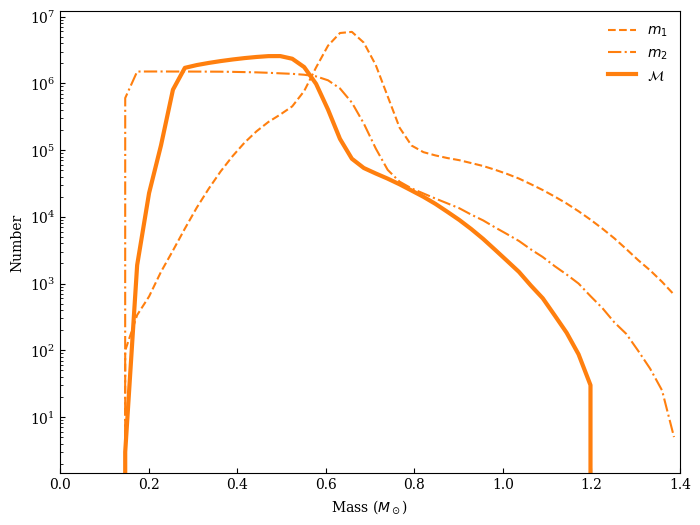

In [32]:
mass_bins = np.linspace(0.08, 1.40, 50)
mass_centres = 0.5 * (mass_bins[:-1] + mass_bins[1:])

fig, ax = plt.subplots(figsize=(8, 6))
for values, linestyle, linewidth, label in [
    (m1.to_value(u.Msun), "--", 1.5, r"$m_1$"),
    (m2.to_value(u.Msun), "-.", 1.5, r"$m_2$"),
    (chirp_mass.to_value(u.Msun), "-", 3.0, r"$\mathcal{M}$"),
]:
    counts, _ = np.histogram(values, bins=mass_bins)
    ax.plot(mass_centres, counts, color="C1", ls=linestyle, lw=linewidth, label=label)

ax.set_yscale("log")
ax.set_xlim(0.0, 1.4)
ax.set_xlabel(r"Mass ($M_\odot$)")
ax.set_ylabel("Number")
ax.legend(frameon=False)
ax.tick_params(which="both", direction="in")
plt.show()


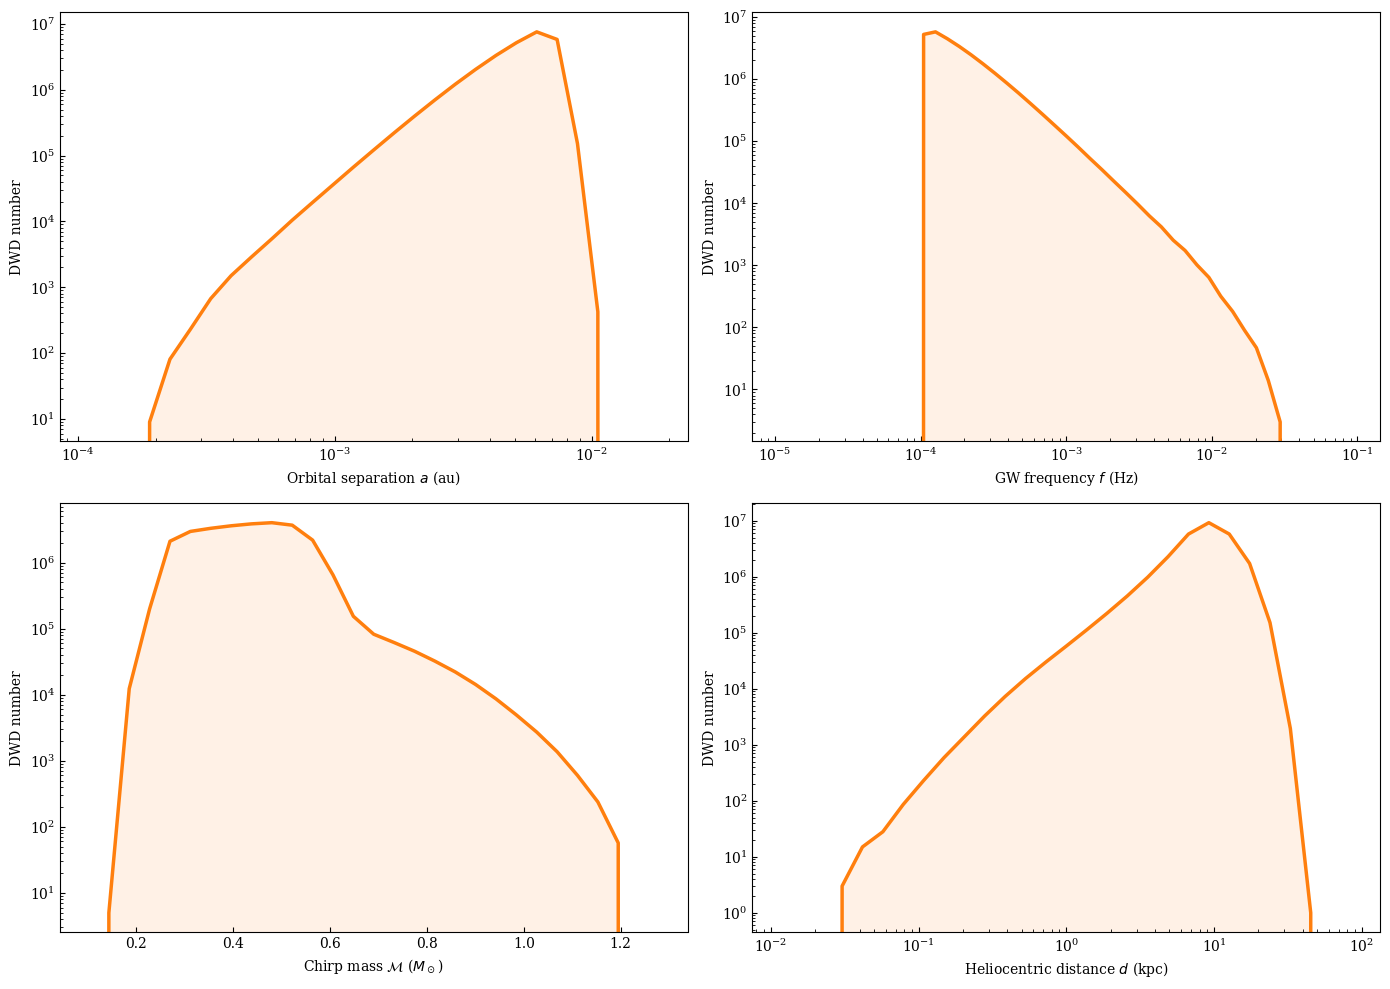

In [33]:
a_edges = np.logspace(-4, np.log10(2.0e-2), 30)
d_edges = np.logspace(-2, 2, 30)
f_edges = np.logspace(np.log10(F_MIN.to_value(u.Hz))-1, -1, 50)
chirp_edges = np.linspace(0.08, 1.30, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_specs = [
    (
        axes[0, 0],
        separation.to_value(u.au),
        a_edges,
        r"Orbital separation $a$ (au)",
        True,
    ),
    (
        axes[0, 1],
        f_gw.to_value(u.Hz),
        f_edges,
        r"GW frequency $f$ (Hz)",
        True,
    ),
    (
        axes[1, 0],
        chirp_mass.to_value(u.Msun),
        chirp_edges,
        r"Chirp mass $\mathcal{M}$ ($M_\odot$)",
        False,
    ),
    (
        axes[1, 1],
        distance.to_value(u.kpc),
        d_edges,
        r"Heliocentric distance $d$ (kpc)",
        True,
    ),
]

for ax, values, edges, xlabel, log_x in plot_specs:
    counts, _ = np.histogram(values, bins=edges)
    centres = (
        np.sqrt(edges[:-1] * edges[1:])
        if log_x
        else 0.5 * (edges[:-1] + edges[1:])
    )
    ax.plot(centres, counts, color="C1", lw=2.5)
    ax.fill_between(centres, counts, color="C1", alpha=0.1)
    ax.set_yscale("log")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("DWD number")
    ax.tick_params(which="both", direction="in")

fig.tight_layout()
plt.show()


## Build and write the LDC-style catalogue

The catalogue columns are

1. $f$ [Hz]
2. $\dot f$ [Hz s$^{-1}$]
3. $\mathcal{A}$
4. ecliptic longitude $\lambda$ [rad], where $\lambda$ varies in $[0,2\pi)$
5. ecliptic latitude $\beta$ [rad]
6. inclination $\iota$ [rad]
7. polarisation $\psi$ [rad]
8. initial phase $\phi_0$ [rad]


In [34]:
f_value = f_gw.to_value(u.Hz)
chirp_mass_kg = chirp_mass.to_value(u.kg)
distance_m = distance.to_value(u.m)

amplitude = (
    2.0
    * (const.G.value * chirp_mass_kg) ** (5.0 / 3.0)
    * (np.pi * f_value) ** (2.0 / 3.0)
    / (distance_m * const.c.value**4)
)

frequency_derivative = (
    96.0
    * np.pi ** (8.0 / 3.0)
    / 5.0
    * (const.G.value * chirp_mass_kg / const.c.value**3) ** (5.0 / 3.0)
    * f_value ** (11.0 / 3.0)
)

inclination = np.arccos(rng.uniform(-1.0, 1.0, N))
polarisation = rng.uniform(0.0, np.pi, N)
initial_phase = rng.uniform(0.0, 2.0 * np.pi, N)

catalogue = np.column_stack([
    f_value,
    frequency_derivative,
    amplitude,
    l_ecl,      
    b_ecl,
    inclination,
    polarisation,
    initial_phase,
])

header = (
    "f [Hz]   dfdt [Hz/s]   AmpPN0   "
    "lambda_ecl [rad,0:2pi)   beta_ecl [rad]   "
    "inc [rad]   psi [rad]   phi0 [rad]"
)

np.savetxt(OUTPUT_FILE, catalogue, fmt="%.12e", header=header)
print(f"Catalogue written to {OUTPUT_FILE}")


Catalogue written to ../datasets/dwd_datasets/DWD_obs_based_population_N26940000.txt


## Verify and plot the saved coordinates

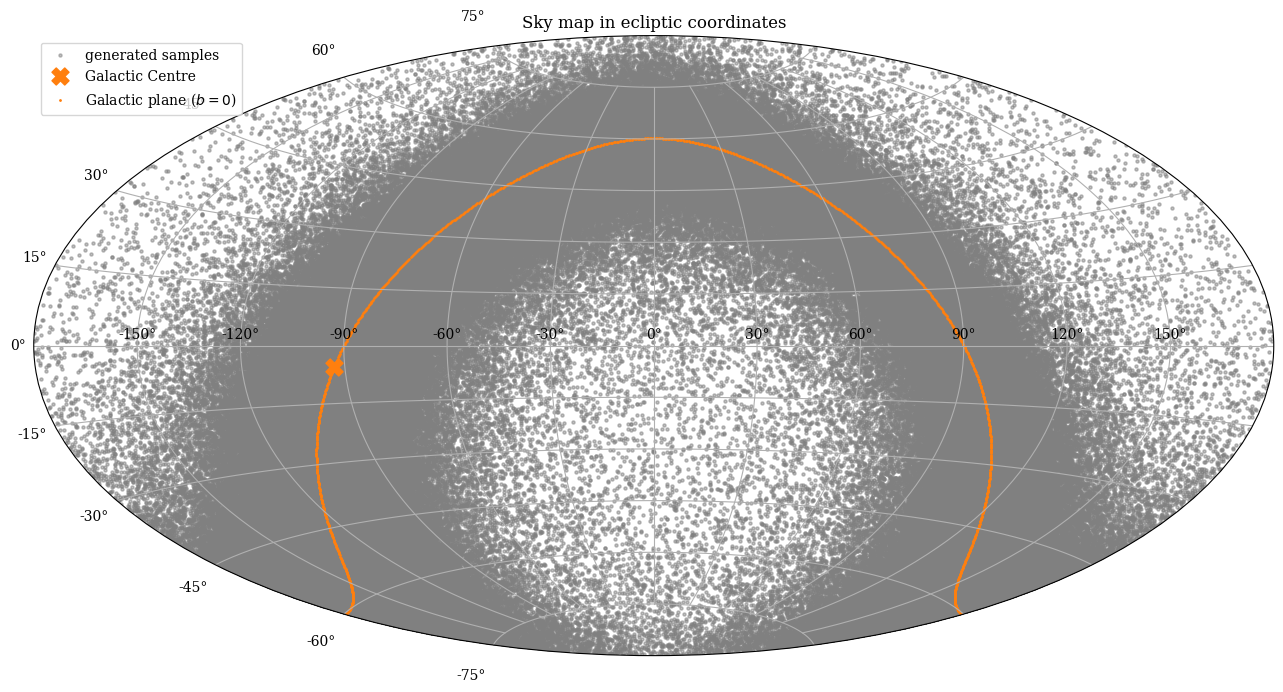

(<Figure size 1600x1000 with 1 Axes>,
 <AitoffAxes: title={'center': 'Sky map in ecliptic coordinates'}>)

In [35]:
saved_catalogue = np.loadtxt(OUTPUT_FILE, comments="#")

saved_l_ecl = saved_catalogue[:, 3]
saved_b_ecl = saved_catalogue[:, 4]

# The stored coordinates should agree with the generated arrays to output precision.
np.testing.assert_allclose(saved_l_ecl, l_ecl, rtol=0.0, atol=5.0e-12)
np.testing.assert_allclose(saved_b_ecl, b_ecl, rtol=0.0, atol=5.0e-12)

# Wrapping is performed internally for display; saved_l_ecl is unchanged.
sky_plot(saved_l_ecl, saved_b_ecl)


## Corner plot of the saved catalogue


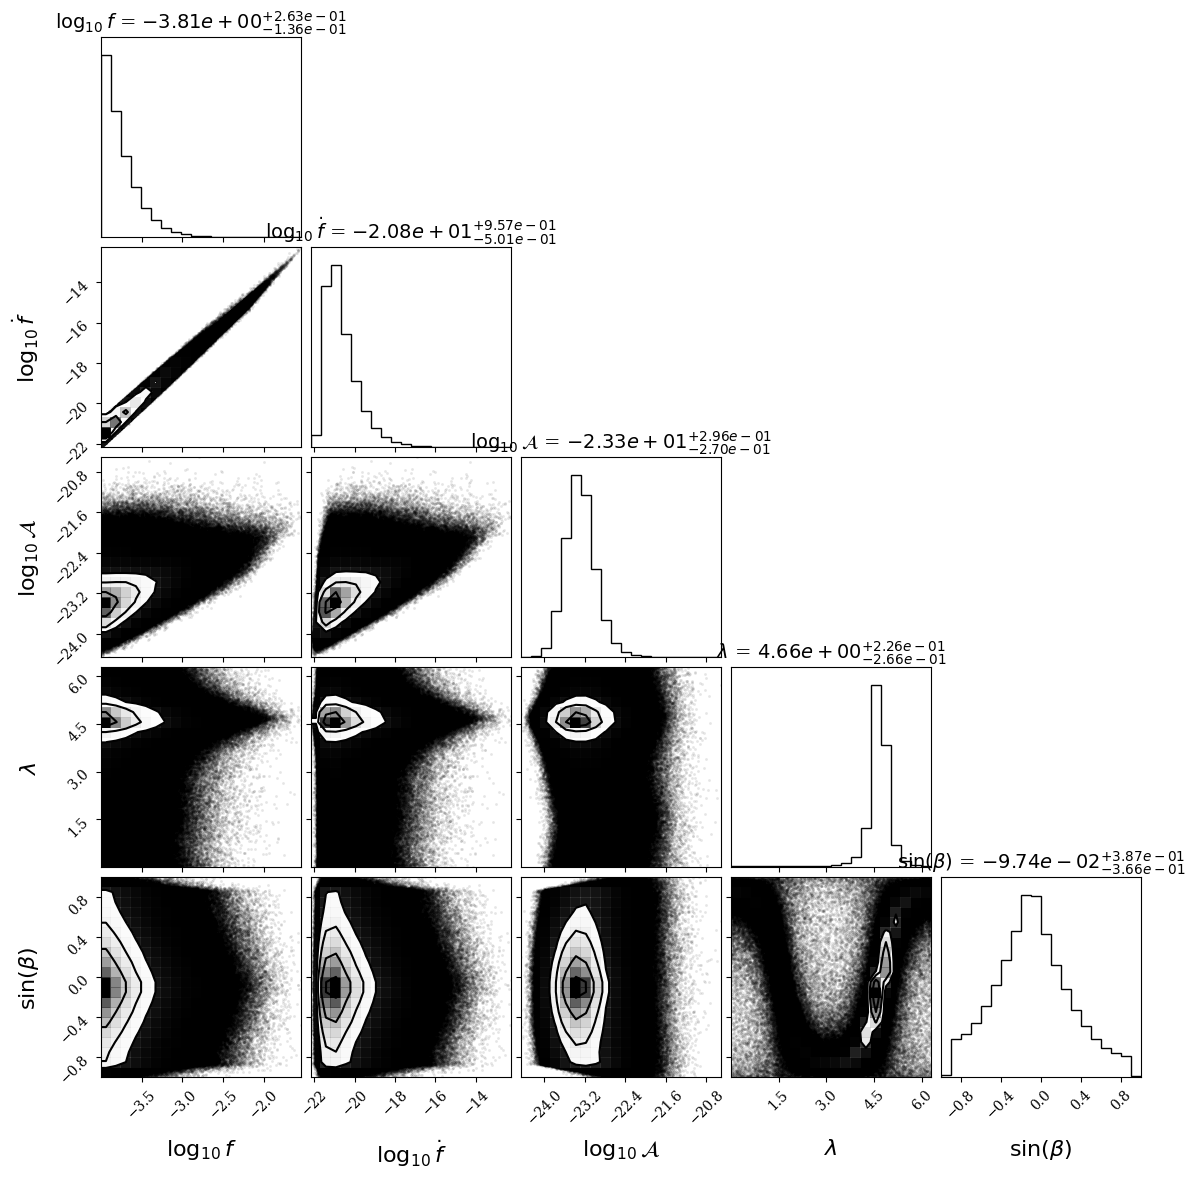

In [36]:
import corner

corner_data = saved_catalogue[:, [0, 1, 2, 3, 4]].copy()
corner_data[:, 0] = np.log10(corner_data[:, 0])
corner_data[:, 1] = np.log10(corner_data[:, 1])
corner_data[:, 2] = np.log10(corner_data[:, 2])
corner_data[:, 4] = np.sin(corner_data[:, 4])

labels = [
    r"$\log_{10} f$",
    r"$\log_{10} \dot{f}$",
    r"$\log_{10} \mathcal{A}$",
    r"$\lambda$",
    r"$\sin(\beta)$",
]

fig = corner.corner(
    corner_data,
    labels=labels,
    show_titles=True,
    title_fmt=".2e",
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 14},
)
plt.show()
